In [1]:
import os, sys, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout, Bidirectional, 
                                     Conv1D, MaxPooling1D, GlobalAveragePooling1D,
                                     BatchNormalization, Activation, Add, 
                                     LayerNormalization, MultiHeadAttention, 
                                     AveragePooling1D, Concatenate, Lambda)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from sklearn.utils import class_weight
from tensorflow.keras.metrics import Precision, Recall
from sklearn.metrics import f1_score
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.utils import plot_model

In [2]:
# This block is used to make the results more reproducible.

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

for gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.enable_op_determinism()
    tf.config.experimental.set_memory_growth(gpu, True)

tf.get_logger().setLevel("ERROR")

In [ ]:
sys.path.append(os.getcwd().replace("\\", "/"))

from Augmentation import (Noise_aug, filter_short_sequences, split_long_seq, GP_aug,
prepare_sequence, AvgPair_aug, ChannelDrop_aug, TimeShift_aug, TimeMask_aug, cap_long_seq,Noise_aug_with_shift)

In [69]:
dir = f'{os.getcwd().replace("\\", "/")}/Data/Mallorn Data corrected'
df = pd.read_csv(f"{dir}/train_df.csv")
df_valid = pd.read_csv(f"{dir}/test_df.csv")
df_test = pd.read_csv(f"{dir}/big_daddy_test.csv")
df.head()

,object_id,Time (MJD),Filter_z_flux,Filter_z_flux_err,Filter_r_flux,Filter_r_flux_err,Filter_y_flux,Filter_y_flux_err,Filter_i_flux,Filter_i_flux_err,Filter_g_flux,Filter_g_flux_err,Filter_u_flux,Filter_u_flux_err,SpecType
0,Dornhoth_fervain_onodrim,63314.4662,-1.895487,0.425312,0.000000,0.000000,-1.601633,1.191244,0.000000,0.000000,0.000000,0.000000,0.0,0.0,AGN
1,Dornhoth_fervain_onodrim,63327.6691,-1.811662,0.462278,0.000000,0.000000,0.000000,0.000000,-1.709337,0.389580,0.000000,0.000000,0.0,0.0,AGN
2,Dornhoth_fervain_onodrim,63340.8720,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.495971,0.403594,0.000000,0.000000,0.0,0.0,AGN
3,Dornhoth_fervain_onodrim,63380.4806,0.000000,0.000000,-1.328391,0.225768,0.000000,0.000000,0.000000,0.000000,-1.253124,0.255106,0.0,0.0,AGN
4,Dornhoth_fervain_onodrim,63420.0891,0.000000,0.000000,-1.396016,0.576872,0.000000,0.000000,0.000000,0.000000,-0.693107,0.241171,0.0,0.0,AGN


In [70]:
# Drop unnecessary columns and apply binary encoding to the `SpecType` column.
A_lambda = [c for c in df.columns if "A_lambda" in c]
dropped =["split","EBV","Z"] + A_lambda
df["target"] = (df["SpecType"] == "TDE").astype(int)
df_valid["target"] = (df_valid["SpecType"] == "TDE").astype(int)
df.drop(columns=["SpecType"], inplace=True), df_test.drop(columns=dropped, inplace=True),df_valid.drop(columns=["SpecType"], inplace=True)
cols = df.drop(columns=["object_id", "Time (MJD)", "target"]).columns.tolist()
target = "target"

In [71]:
df.describe()

,Time (MJD),Filter_z_flux,Filter_z_flux_err,Filter_r_flux,Filter_r_flux_err,Filter_y_flux,Filter_y_flux_err,Filter_i_flux,Filter_i_flux_err,Filter_g_flux,Filter_g_flux_err,Filter_u_flux,Filter_u_flux_err,target
count,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000
mean,62912.220715,0.227919,0.192453,0.259344,0.087707,0.147404,0.317267,0.266568,0.133547,0.097125,0.029592,0.059831,0.065664,0.050926
std,908.440751,1.417704,0.324072,1.550385,0.148462,1.321489,0.614922,1.507618,0.215179,1.076593,0.088921,1.063625,0.196766,0.219848
min,60979.598400,-20.403083,0.000000,-19.101684,0.000000,-15.165649,0.000000,-20.979804,0.000000,-28.582649,0.000000,-46.764388,0.000000,0.000000
25%,62199.276300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,62967.419900,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,63599.091025,0.000000,0.409453,0.000000,0.164983,0.000000,0.000000,0.000000,0.258408,0.000000,0.000000,0.000000,0.000000,0.000000
max,64632.737000,63.939762,7.811669,65.606458,4.914303,106.839852,8.538723,56.818243,7.395473,98.624511,5.359896,133.079466,18.236183,1.000000


In [ ]:
# Cap the length of the sequences and remove short sequences
df = cap_long_seq(df, "object_id", max_len=100)
df_valid = cap_long_seq(df_valid, "object_id", max_len=100)
df_test = cap_long_seq(df_test, "object_id", max_len=100)
df = filter_short_sequences(df, "object_id", min_len=30)
print(df['object_id'].value_counts())

object_id
yll_lebenedh_cair           100
Dornhoth_anwar_melethron    100
Dornhoth_archam_grond       100
Dornhoth_certh_iaun         100
yll_Mirion_hud              100
                           ... 
firion_lorn_certh            31
bain_gwaloth_navaer          31
fast_celeb_bregedur          30
lebenedh_imrad_adab          30
yll_tamin_fern               30
Name: count, Length: 2409, dtype: int64


In [73]:
round(pd.DataFrame(df[target].value_counts())/df.shape[0],2)

,count
target,
0,0.95
1,0.05


In [ ]:
# convert DF → padded sequences
X_train, y_train, X_final = prepare_sequence(df, df_test, "object_id", cols, target)
X_valid, y_valid, _ = prepare_sequence(df_valid, df_test, "object_id", cols, target)

# Add some random noise to the data
X_noise_positive, y_noise_positive = Noise_aug(X_train, y_train, noise_level=0.1, n_aug=2, balance=True)
X_noise, y_noise = Noise_aug(X_train, y_train, noise_level=0.1, n_aug=1)

# GP: add gaussian noise with the mean and the variance be per light curve per channel
# X_syn_positive, y_syn_positive = GP_aug(X_train, y_train, n_aug=2, balance=True)
# X_syn, y_syn = GP_aug(X_train, y_train, n_aug=1)

# replacing each point with the average of the before and after point
X_avg, y_avg = AvgPair_aug(X_train, y_train, n_aug=1)

# Flux Shift
X_flux_shi, y_flux_shi = Noise_aug_with_shift(X_train, y_train, n_aug=1, shift_range=(-5, 5), balance=True)

# Time shift
X_shi, y_shi = TimeShift_aug(X_train, y_train, n_aug=1)

# Time mask
X_mas, y_mas = TimeMask_aug(X_train, y_train, n_aug=1)

In [ ]:
stop

In [75]:
# Create an augmented version of the validation data to test the model
X_noise_t, y_noise_t = Noise_aug(X_valid, y_valid, noise_level=0.1, n_aug=1)
X_syn_t, y_syn_t = TimeShift_aug(X_valid, y_valid, n_aug=1)
X_avg_t, y_avg_t = AvgPair_aug(X_valid, y_valid, n_aug=1)

X_valid_aug = np.concatenate([X_valid,X_noise_t,X_syn_t,X_avg_t], axis=0)
y_valid_aug = np.concatenate([y_valid,y_noise_t,y_syn_t,y_avg_t], axis=0)

perm = np.random.permutation(len(y_valid_aug))
X_valid_aug = X_valid_aug[perm]
y_valid_aug = y_valid_aug[perm]

print(X_valid_aug.shape)
print(y_valid_aug.shape)

(2436, 100, 12)
(2436,)


In [11]:
# Compine all the data
X_combined = np.concatenate([X_train, X_noise, X_syn, X_syn_positive, X_noise_positive, X_avg, X_shi, X_mas, X_flux_shi], axis=0)
y_combined = np.concatenate([y_train, y_noise, y_syn, y_syn_positive, y_noise_positive, y_avg, y_shi, y_mas, y_flux_shi], axis=0)

perm = np.random.permutation(len(y_combined))
X_combined = X_combined[perm]
y_combined = y_combined[perm]

print(X_combined.shape)
print(y_combined.shape)

(15039, 100, 12)
(15039,)


In [ ]:
def modelS():
    model = Sequential([
        Input(shape=(X_train.shape[1], X_train.shape[2]), name="Input_CF"),
        Lambda(lambda t: -1*t),
        
        Conv1D(64, kernel_size=3, padding="same", activation="relu", dilation_rate=1, name="Conv_AF"),
        AveragePooling1D(pool_size=2,name="Pool_AF"),

        Conv1D(256, kernel_size=3, padding="same", activation="relu", dilation_rate=2, name="Conv_BF"),
        AveragePooling1D(pool_size=2,name="Pool_BF"),

        Conv1D(512, kernel_size=3, padding="same", activation="relu", dilation_rate=4, name="Conv_CF"),
        Dropout(0.1,name="Dropout_AF"),
        GlobalAveragePooling1D(name="Pool_CF"),

        Dense(128, activation="relu", name="Dense_AF"),
        Dropout(0.3,name="Dropout_BF"),
        
        Dense(32, activation="relu", name="Dense_BF"),
        Dropout(0.3,name="Dropout_CF"),

        Dense(1, activation="sigmoid", name="Dense_CF")
    ])
    return model

In [13]:
# Create class weights to help the model handle data imbalance
classes = np.unique(y_combined)
weights = class_weight.compute_class_weight(class_weight='balanced', classes=classes, y=y_combined)
class_weights = dict(zip(classes, weights))

In [14]:
# Model training with early stopping
early_stop = EarlyStopping(
        monitor="val_aucpr",
        patience=20,
        verbose=1,
        restore_best_weights=True,
        start_from_epoch=5,
)

base_model = modelS()

base_model.compile(
    optimizer=Adam(
        learning_rate=0.0005,
        gradient_accumulation_steps=10
    ),
    loss="binary_crossentropy",
    metrics=[Precision(name="precision"), Recall(name="recall"), tf.keras.metrics.AUC(curve="PR", name="aucpr")]
)

history = base_model.fit(
    X_combined,
    y_combined,
    epochs=100,
    batch_size=128,
    validation_data=(X_valid, y_valid),
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - aucpr: 0.1016 - loss: 0.6897 - precision: 0.0958 - recall: 0.6286 - val_aucpr: 0.0648 - val_loss: 0.6965 - val_precision: 0.0621 - val_recall: 0.9000
Epoch 2/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - aucpr: 0.1803 - loss: 0.6703 - precision: 0.1095 - recall: 0.6861 - val_aucpr: 0.0661 - val_loss: 0.6534 - val_precision: 0.0805 - val_recall: 0.6333
Epoch 3/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - aucpr: 0.2260 - loss: 0.6335 - precision: 0.1338 - recall: 0.6791 - val_aucpr: 0.0688 - val_loss: 0.5699 - val_precision: 0.0610 - val_recall: 0.3333
Epoch 4/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - aucpr: 0.2701 - loss: 0.5958 - precision: 0.1533 - recall: 0.7055 - val_aucpr: 0.0727 - val_loss: 0.5307 - val_precision: 0.0710 - val_recall: 0.4333
Epoch 5/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - aucpr: 0.3118 - loss: 0.5602 - precision: 0.1654 - recall: 0.7319 - val_aucpr: 0.0886 - val_loss: 0.5413 - val_precisio

max AUCPR 0.437


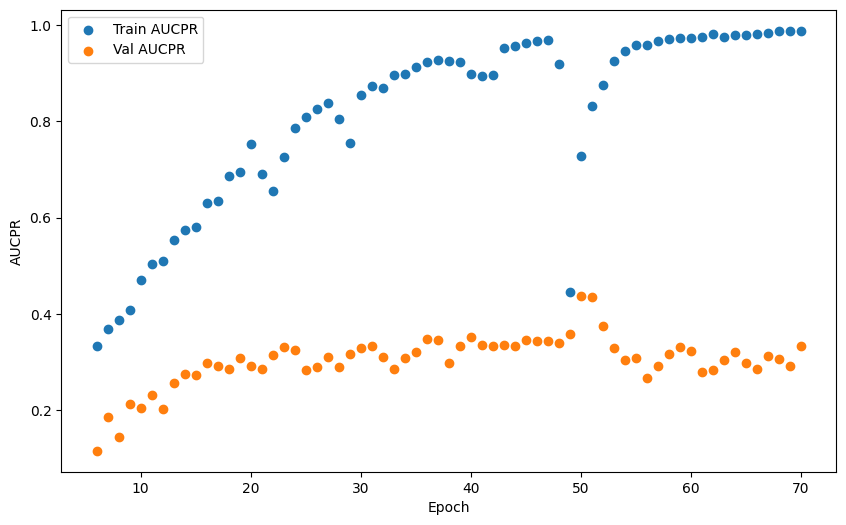

In [15]:
# Plot training and validation AUCPR versus epochs
epochs = range(1, len(history.history["aucpr"]) + 1)
max_auc = max(history.history["val_aucpr"])
print(f"max AUCPR {round(max_auc,3)}")
plt.figure(figsize=(10, 6))
plt.scatter(epochs[5:], history.history["aucpr"][5:], label="Train AUCPR")
plt.scatter(epochs[5:], history.history["val_aucpr"][5:], label="Val AUCPR")
plt.xlabel("Epoch")
plt.ylabel("AUCPR")
plt.legend()
plt.show()

In [52]:
# Prepare the models by removing their classification heads and freezing their weights
models = [
    # load_model("D:/Mallorn/models/model_1_v2.keras"),
    load_model("D:/Mallorn/models/final_model.keras"),
    # load_model("D:/Mallorn/models/model_3_v2.keras"),
    base_model
]

feature_extractors = []
for m in models:
    try:
        feat = Model(inputs=m.input, outputs=m.layers[-6].output)
    except:
        feat = Model(inputs=m.layers[0].input, outputs=m.layers[-6].output)
    for l in feat.layers:
        l.trainable = False
    feature_extractors.append(feat)

m1_feat, m2_feat = feature_extractors

In [53]:
# Ensemble the models by merging them horizontly
shared_input = Input(shape=X_train.shape[1:])

f1 = m1_feat(shared_input)
f2 = m2_feat(shared_input)
# f3 = m3_feat(shared_input)
# f4 = m4_feat(shared_input)

merged = Concatenate()([f1, f2])

x = Dense(512, activation="relu")(merged)
x = Dropout(0.3)(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)
out = Dense(1, activation="sigmoid")(x)

final_model = Model(
    inputs=shared_input,
    outputs=out
)

In [55]:
# Training the final model to fine tune it
early_stop = EarlyStopping(
        monitor="val_aucpr",
        patience=20,
        verbose=1,
        restore_best_weights=True,
        start_from_epoch=5,
)

final_model.compile(
    optimizer=Adam(
        learning_rate=0.00005,
        gradient_accumulation_steps=12,),
    loss="binary_crossentropy",
    metrics=[Precision(name="precision"),tf.keras.metrics.AUC(curve="PR", name="aucpr")]
)

history = final_model.fit(
    X_combined,
    y_combined,
    epochs=80,
    batch_size=128,
    validation_data=(X_valid, y_valid),
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/80
118/118 ━━━━━━━━━━━━━━━━━━━━ 26s 155ms/step - aucpr: 0.1273 - loss: 0.7098 - precision: 0.1177 - val_aucpr: 0.3322 - val_loss: 0.5809 - val_precision: 0.1116
Epoch 2/80
118/118 ━━━━━━━━━━━━━━━━━━━━ 17s 141ms/step - aucpr: 0.2755 - loss: 0.5871 - precision: 0.1676 - val_aucpr: 0.3752 - val_loss: 0.5314 - val_precision: 0.1304
Epoch 3/80
118/118 ━━━━━━━━━━━━━━━━━━━━ 17s 140ms/step - aucpr: 0.4011 - loss: 0.5168 - precision: 0.2103 - val_aucpr: 0.3984 - val_loss: 0.4642 - val_precision: 0.1520
Epoch 4/80
118/118 ━━━━━━━━━━━━━━━━━━━━ 17s 140ms/step - aucpr: 0.4564 - loss: 0.4796 - precision: 0.2356 - val_aucpr: 0.3869 - val_loss: 0.4574 - val_precision: 0.1486
Epoch 5/80
118/118 ━━━━━━━━━━━━━━━━━━━━ 17s 142ms/step - aucpr: 0.5376 - loss: 0.4385 - precision: 0.2694 - val_aucpr: 0.4017 - val_loss: 0.4170 - val_precision: 0.1733
Epoch 6/80
118/118 ━━━━━━━━━━━━━━━━━━━━ 17s 141ms/step - aucpr: 0.5816 - loss: 0.4039 - precision: 0.2821 - val_aucpr: 0.4233 - val_loss: 0.3652 - val_prec

In [31]:
# base_model.save("D:/Mallorn/models/base_model_v3.keras")

In [3]:
our_model = tf.keras.models("d:/New/Mallorn/models/model_3_v2.keras")

TypeError: 'module' object is not callable

In [54]:
# Plot the architecture of the model
plot_model(
    final_model,
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True
)

In [56]:
# # Final fine Tunning of the model
# final_model.compile(
#     optimizer=Adam(
#         learning_rate=0.00001,
#         gradient_accumulation_steps=12,),
#     loss="binary_crossentropy",
#     metrics=[Precision(name="precision"),tf.keras.metrics.AUC(curve="PR", name="aucpr")]
# )

# history = final_model.fit(
#     X_valid,
#     y_valid,
#     epochs=10,
#     batch_size=128,
#     validation_data=(X_valid, y_valid),
#     class_weight=class_weights,
#     callbacks=[early_stop],
#     verbose=1
# )

min val_loss 0.188


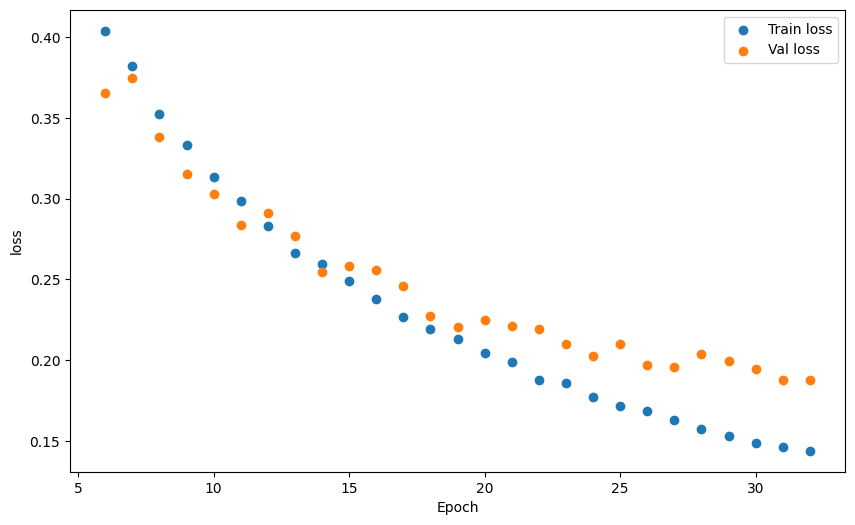

In [57]:
# Plot training and validation loss versus epochs
epochs = range(1, len(history.history["loss"]) + 1)
min_loss = min(history.history["val_loss"])
print(f"min val_loss {round(min_loss,3)}")
plt.figure(figsize=(10, 6))
plt.scatter(epochs[5:], history.history["loss"][5:], label="Train loss")
plt.scatter(epochs[5:], history.history["val_loss"][5:], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

max AUCPR 0.441


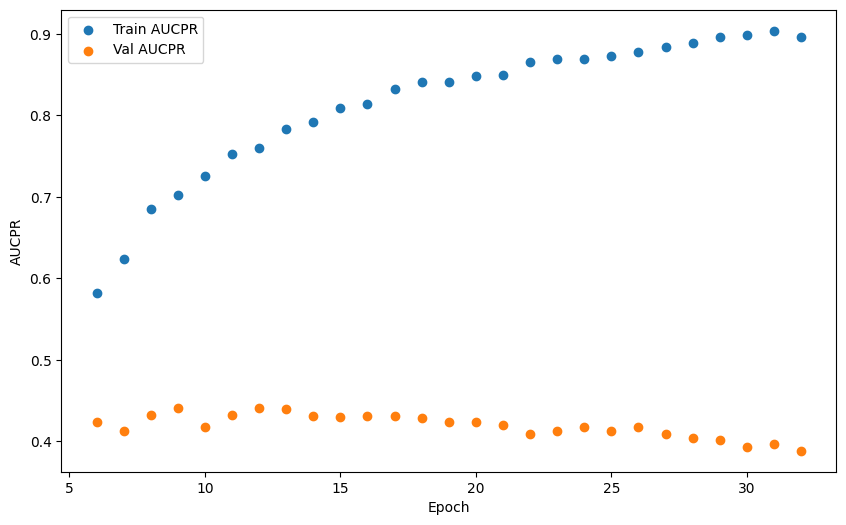

In [58]:
# Plot training and validation AUCPR versus epochs
epochs = range(1, len(history.history["aucpr"]) + 1)
max_auc = max(history.history["val_aucpr"])
print(f"max AUCPR {round(max_auc,3)}")
plt.figure(figsize=(10, 6))
plt.scatter(epochs[5:], history.history["aucpr"][5:], label="Train AUCPR")
plt.scatter(epochs[5:], history.history["val_aucpr"][5:], label="Val AUCPR")
plt.xlabel("Epoch")
plt.ylabel("AUCPR")
plt.legend()
plt.show()

In [59]:
y_pred_prob = final_model.predict(X_train, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
f1 = f1_score(y_train, y_pred)
print("Training F1 score:", round(f1,4))

Training F1 score: 0.4845


In [60]:
y_pred_prob = final_model.predict(X_combined, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
f1 = f1_score(y_combined, y_pred)
print("Validation_aug F1 score:", round(f1,4))

Validation_aug F1 score: 0.5983


In [61]:
y_pred_prob = final_model.predict(X_valid_aug, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
f1 = f1_score(y_valid_aug, y_pred)
print("Validation_aug F1 score:", round(f1,4))

Validation_aug F1 score: 0.3385


In [62]:
y_pred_prob = final_model.predict(X_valid, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
f1 = f1_score(y_valid, y_pred)
print("Validation F1 score:", round(f1,4))

Validation F1 score: 0.3415


In [63]:
# a function that find the best threshold of the f1_score
def find_best_threshold(model, X_valid, y_valid):
    max_f1 = 0
    best_thr = 0
    
    y_pred = model.predict(X_valid, verbose=0)
    
    for t in np.linspace(0.05, 0.95, 201):
        f1 = f1_score(y_valid, y_pred > t)
        if f1 > max_f1:
            max_f1 = f1
            best_thr = t
    
    print(f"Best F1: {max_f1:.3f} at threshold {best_thr:.3f}")
    return best_thr, max_f1


In [64]:
# Check the f1 of the X_train
_,_ = find_best_threshold(final_model, X_train, y_train)

Best F1: 0.790 at threshold 0.770


In [65]:
# Check the f1 of the X_valid_aug
_,_ = find_best_threshold(final_model, X_valid_aug, y_valid_aug)

Best F1: 0.472 at threshold 0.662


In [76]:
# Check the f1 of the X_valid
best_thr, _ =find_best_threshold(final_model, X_valid, y_valid)

Best F1: 0.519 at threshold 0.639


In [ ]:
# Final submission
y_pred_prob = base_model.predict(X_final)
y_pred = (y_pred_prob > 0.7).astype(int).flatten()

object_ids = df_test.groupby("object_id").first().index
sub = pd.DataFrame({
    "object_id": object_ids,
    "prediction": y_pred
})
sub.to_csv(f"{os.getcwd().replace("\\", "/")}/submission/big_model_submission.csv", index=False)

223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
